## Section 1: Get that data!

As a data analysis side project, I decided to use data on music my friends and I have listened to in order to see if there are any patterns in the data that would separate our tastes.

The back story: Back in high school (a long, long time ago for me!), I was big into music. I played in a garage band (I thank my lucky stars this was before the internet was a real thing), my friends had bands, we went to concerts all the time. I *loved* music. I was into all the great bands around in that era - Red Hot Chili Peppers, Primus, Nirvana, Beck. I could go on. I was so into music, I got my undergrad degree in Music Business and set out to work for a music company in L.A. But after a few years, I got the itch to be even more involved in the creative process. Crazy enough, I came to the conclusion that the best way for me to do that was to leave music and get into genomics, where I could be creative with data analysis. It was a crazy idea, and I had no business thinking I could make the transition, but I took a leap anyway. When I left the music business, I sort of moved away from music a whole. I listened to some music, but not much. I stopped going to concerts. I stopped discovering new bands. I was busy with other things - school, work, family. As fate would have it, I moved back to my hometown for a job in 2018 and reconnected with some of my friends from back in the day. One friend had the brilliant idea of starting an album club. Like a book club, but albums instead of books. Each session, we'd each pick an album we wanted to listen to (there are 6 of us), and then we'd all listen to all the albums before we met again. Then we'd get together to discuss all the albums. It's been awesome! We've listened to so much music. Some old, some new. Lots of different genres. We've gone on Album Club Field Trips to concerts. We've gotten to hang and talk music like old times. At this point, we've met about 16 times and nominated almost 100 albums with well over 1,000 tracks. It's been awesome. You should totally do this too!

As I was thinking about side-projects to try out analysis approaches on, I wondered if I could gain any insights into the music we've nominated with data science tools. Sort of bringing my two worlds together. So I set out to collect available data on our musical choices and see if there were any major patterns. Collecting basic metadata about the musical choices we had made was easy, because Spotify makes this all accesible through their API (Application Programming Interface), if you have a developer membership set up. However, collecting quantitative features of the musical attributes of the tracks proved trickier (though not insurmountable). 

## Collecting Data
Step 1 - Set up a Spotify web developer account (developer.spotify.com). And create an app. Then use Python to pull info on our playlists. It turns out that before 2025, you could download musical features directly from Spotify, however (because late-stage capitalism, this is no longer true. Fortunately, there are other sites that make this kind of information available, and one is even free as of March 2026! It's called ReccoBeats and is basically an API that lets you download these attributes. It has its own internal ID system for songs, but if you are submitting a batch query, it will accept a list of Spotify IDs.

In full disclosure, I used Claude to help figure out a lot of the data scraping steps. All the data cleaning and analysis steps were my own. Claude couldn't figure out how to get musical features from ReccoBeats on its own, but after I did a little sleuthing, I found this great blog post (https://www.lewisdoesdata.com/2025/11/05/rescuing-a-reproducibility-fail.html), which helped us overcome the obstacle (you're welcome, Claude!).

In [2]:
#Make redirect URIs = http://127.0.0.1:9001/callback
#Client ID: [Enter yours here]
#Client Secret: [Enter yours here]
#Playlist URL: https://open.spotify.com/playlist/2ApYepNY2FO7SZqmeFhYSA
#To find environment:
#    import sys
#    print(sys.executable)
#To install libraries, first run `source python_envs/python3.13/bin/activate`

In [411]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
import pandas as pd
import requests
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import time
import umap

In [258]:
CLIENT_ID = "[Enter yours here]"
CLIENT_SECRET = "[Enter yours here]"
PLAYLIST_ID = "2ApYepNY2FO7SZqmeFhYSA"  # e.g. "37i9dQZF1DXcBWIGoYBM5M"
REDIRECT_URI = "http://127.0.0.1:9001/callback"
OUTPUT_FILE = "./album_club_audio_features.csv"
RAW_OUTPUT_FILE = "./album_club_raw_audio_features.csv"
META_FILE = "./album_club_albums_meta.csv"
BATCH_SIZE = 5      # conservative, per the blog post
PAUSE = 0.5         # seconds between requests

In [259]:
# Authenticate
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    redirect_uri=REDIRECT_URI,
    scope="playlist-read-private playlist-read-collaborative",
    cache_path=".spotify_cache"
))

In [260]:
# Get all tracks from Spotify (paginated)
print("Fetching playlist tracks...")
tracks = []
results = sp.playlist_items(PLAYLIST_ID)

while results:
    for item in results["items"]:
        track = item.get("item")
        if track and track.get("id") and track.get("type") == "track":
            album = track.get("album", {})
            tracks.append({
                "id": track["id"],
                "name": track["name"],
                "artist": ", ".join(a["name"] for a in track["artists"]),
                "album": album.get("name"),
                "album_type": album.get("album_type"),
                "release_date": album.get("release_date"),
                "popularity": track.get("popularity"),
                "duration_ms": track["duration_ms"],
                "duration_min": round(track["duration_ms"] / 60000, 2),
                "explicit": track["explicit"],
                "track_number": track.get("track_number"),
                "isrc": track.get("external_ids", {}).get("isrc"),
                "spotify_url": track.get("external_urls", {}).get("spotify"),
                "added_at": item.get("added_at"),
            })
    results = sp.next(results) if results["next"] else None

print(f"Found {len(tracks)} tracks.")
df = pd.DataFrame(tracks)

Fetching playlist tracks...
Found 1242 tracks.


In [261]:
# ReccoBeats — batch by Spotify IDs
# Endpoint: GET https://api.reccobeats.com/v1/audio-features?ids=id1,id2,...
# Accepts Spotify track IDs directly (up to ~5 per request to stay safe)
# No API key required. Returns content[] array with audio features per track.
# Required insights from this blog post: https://www.lewisdoesdata.com/2025/11/05/rescuing-a-reproducibility-fail.html

RECCOBEATS_URL = "https://api.reccobeats.com/v1/audio-features"
RECCO_COLS = ["acousticness", "danceability", "energy", "instrumentalness",
              "liveness", "loudness", "speechiness", "tempo", "valence"]

def get_reccobeats_batch(spotify_ids, retries=3):
    """Fetch audio features for a batch of Spotify IDs from ReccoBeats."""
    params = {"ids": ",".join(spotify_ids)}
    for attempt in range(retries):
        try:
            r = requests.get(RECCOBEATS_URL, params=params, timeout=15)
            if r.status_code == 200:
                data = r.json()
                content = data.get("content", [])
                # content is a list of feature dicts; extract Spotify ID from href field
                results = {}
                for item in content:
                    href = item.get("href", "")
                    spotify_id = href.replace("https://open.spotify.com/track/", "").strip()
                    results[spotify_id] = {k: item.get(k) for k in RECCO_COLS}
                return results
            elif r.status_code == 429:
                wait = int(r.headers.get("Retry-After", 10))
                print(f"  Rate limited, waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"  ReccoBeats {r.status_code}: {r.text[:100]}")
                return {}
        except requests.RequestException as e:
            print(f"  Request error (attempt {attempt+1}): {e}")
            time.sleep(2)
    return {}

print("\nFetching ReccoBeats audio features...")
recco_results = {}
track_ids = [t["id"] for t in tracks]

# batch into groups of BATCH_SIZE
batches = [track_ids[i:i+BATCH_SIZE] for i in range(0, len(track_ids), BATCH_SIZE)]

for i, batch in enumerate(batches):
    batch_results = get_reccobeats_batch(batch)
    recco_results.update(batch_results)
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(batches)} batches done, {len(recco_results)} tracks with features...")
    time.sleep(PAUSE)

print(f"ReccoBeats: got features for {len(recco_results)}/{len(tracks)} tracks.")

for col in RECCO_COLS:
    df[f"recco_{col}"] = df["id"].map(
        lambda tid, c=col: recco_results.get(tid, {}).get(c)
    )
#df.to_csv(RAW_OUTPUT_FILE, index=False)


Fetching ReccoBeats audio features...
  20/249 batches done, 91 tracks with features...
  40/249 batches done, 181 tracks with features...
  60/249 batches done, 281 tracks with features...
  80/249 batches done, 359 tracks with features...
  100/249 batches done, 459 tracks with features...
  120/249 batches done, 547 tracks with features...
  140/249 batches done, 647 tracks with features...
  160/249 batches done, 747 tracks with features...
  180/249 batches done, 839 tracks with features...
  200/249 batches done, 932 tracks with features...
  220/249 batches done, 1021 tracks with features...
  240/249 batches done, 1082 tracks with features...
ReccoBeats: got features for 1107/1242 tracks.


In [587]:
#So we can read the raw download back in if we want
df = pd.read_csv(RAW_OUTPUT_FILE)

## Section 2: Analyze that data!

### Notes:
Having downloaded the playlist and grabbed the musical features (you can read more about what the different features mean here: https://reccobeats.com/docs/apis/get-track-audio-features), I first wanted to check the completeness of the data

In [549]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1242 entries, 0 to 1241
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1242 non-null   object 
 1   name                    1242 non-null   object 
 2   artist                  1242 non-null   object 
 3   album                   1242 non-null   object 
 4   album_type              1242 non-null   object 
 5   release_date            1242 non-null   object 
 6   popularity              50 non-null     float64
 7   duration_ms             1242 non-null   int64  
 8   duration_min            1242 non-null   float64
 9   explicit                1242 non-null   bool   
 10  track_number            1242 non-null   int64  
 11  isrc                    1242 non-null   object 
 12  spotify_url             1242 non-null   object 
 13  added_at                1242 non-null   object 
 14  recco_acousticness      1106 non-null   

### Notes:

Popularity doesn't have a lot of filled values, so I got rid of it.

In [588]:
df = df.drop(["popularity"],axis=1)

### Notes:

It looked like the music features from ReccoBeats were missing from the same songs. So I wanted to know if the missing values were systematic (i.e., affecting whole albums) or one-offs.

In [551]:
null_rows_any = df[df.isnull().any(axis=1)]
null_rows_any["album"].value_counts()

album
Teenager of the Year                                                     22
Sometimes I Sit and Think, and Sometimes I Just Sit (Special Edition)    17
The Crossing                                                             15
Bleeds                                                                   12
Disintegration (2010 Remaster)                                           12
Getting Killed                                                           11
Guitars, Cadillacs, Etc., Etc.                                           10
Kaputt                                                                    9
Ege Bamyasi (Remastered Version)                                          7
Violent Femmes                                                            1
Wha'ppen?                                                                 1
The Specials                                                              1
The Head on the Door (Deluxed Edition)                                    1
London

### Notes:
It looks like a few albums are missing musical attributes for most/all of their songs (e.g., Teenager of the Year, Sometimes I Sit and Think..., etc.) and some are just missing it for one song (e.g., POST-). Many of the one-offs happen to be from a movie soundtrack (Grosse Point Blank), so maybe that soundtrack hasn't been put in the ReccoBeats db. I decided to just remove all the tracks that didn't have musical features.

In [552]:
df = df.dropna()
df = df.reset_index(drop=True)

### Notes:
After confirming, that we have a nice complete DataFrame, with no null values, I saved it again.

In [554]:
df.info()
#df.to_csv(OUTPUT_FILE, index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1106 entries, 0 to 1105
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1106 non-null   object 
 1   name                    1106 non-null   object 
 2   artist                  1106 non-null   object 
 3   album                   1106 non-null   object 
 4   album_type              1106 non-null   object 
 5   release_date            1106 non-null   object 
 6   duration_ms             1106 non-null   int64  
 7   duration_min            1106 non-null   float64
 8   explicit                1106 non-null   bool   
 9   track_number            1106 non-null   int64  
 10  isrc                    1106 non-null   object 
 11  spotify_url             1106 non-null   object 
 12  added_at                1106 non-null   object 
 13  recco_acousticness      1106 non-null   float64
 14  recco_danceability      1106 non-null   

In [643]:
df = pd.read_csv(OUTPUT_FILE)

In [644]:
df['release_date'] = pd.to_datetime(df['release_date'],format='mixed')
df['Year'] = df['release_date'].dt.year

### Notes:
In a separate spreadsheet, I had collected some data about the albums - the record label, who in our club selected it, when they selected it, etc. I wanted to merge that data with the track info, so I read that table in next.

In [645]:
meta = pd.read_csv(META_FILE)

In [631]:
meta.head()

,Artist,Album,Round,Selector,Year,Total Tracks,Total Time,Ave. Track Time,Gender of Lead Singer,Unnamed: 9,...,Country,Record Label,Parent Label,AFW Fave,DC Fave,EB Fave,IP Fave,JE Fave,JD Fave,Most Popular Song
0,Stevie Wonder,Songs In The Key Of Life,1,DC,1976,21,105,5.0,Male,1.0,...,USA,Motown Records,Universal Music Group,Pastime Paradise,I wish,As,As,All Day Sucker,NaN,As
1,Talking Heads,Remain in Light,1,JE,1980,8,40,5.0,Male,1.0,...,USA,Sire Records,Warner Music Group,The Great Curve,Listening wind,the famous one,Once In A Lifetime,Born Under Punches,NaN,NaN
2,Destroyer,Kaputt,1,IP,2011,9,50,5.6,Male,1.0,...,Canada,Merge Records,Independent,Poor in Love,Savage night at the opera,Kaputt,Kaputt,Chinatown,NaN,Kaputt
3,Bruce Springstein,Wrecking Ball,1,AFW,2012,13,61,4.7,Male,1.0,...,USA,Columbia Records,Sony Music Entertainment,Shackled and Drawn,Death to my hometown,wrecking ball,We Take Care Of Our Own,Wrecking Ball,NaN,wrecking ball
4,Ziggy Marley,Rebellion Rises,1,EB,2018,10,35,3.5,Male,1.0,...,Jamaica,Tuff Gong Worldwide,Independent,Your Pain is Mine,I will be glad,Change your world,The Storm Is Coming,Change Your World,NaN,Change your world


In [646]:
meta.columns

Index(['Artist', 'Album', 'Round', 'Selector', 'Year', 'Total Tracks',
       'Total Time', 'Ave. Track Time', 'Gender of Lead Singer', 'Unnamed: 9',
       'Origin City', 'State (if USA)', 'Country', 'Record Label',
       'Parent Label', 'AFW Fave', 'DC Fave', 'EB Fave', 'IP Fave', 'JE Fave',
       'JD Fave', 'Most Popular Song'],
      dtype='object')

In [647]:
df.columns

Index(['id', 'name', 'artist', 'album', 'album_type', 'release_date',
       'duration_ms', 'duration_min', 'explicit', 'track_number', 'isrc',
       'spotify_url', 'added_at', 'recco_acousticness', 'recco_danceability',
       'recco_energy', 'recco_instrumentalness', 'recco_liveness',
       'recco_loudness', 'recco_speechiness', 'recco_tempo', 'recco_valence',
       'Year'],
      dtype='object')

In [648]:
meta = meta[['Artist','Album', 'Round', 'Selector', 'Gender of Lead Singer',
       'Origin City', 'State (if USA)', 'Country', 'Record Label',
       'Parent Label']]

In [649]:
merged_df = pd.merge(df, meta, left_on='album', right_on='Album', how='left')
merged_df = merged_df.drop(columns=["Artist","Album"],axis=1)
merged_df = merged_df.dropna()
merged_df = merged_df.reset_index(drop=True)
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      1081 non-null   object        
 1   name                    1081 non-null   object        
 2   artist                  1081 non-null   object        
 3   album                   1081 non-null   object        
 4   album_type              1081 non-null   object        
 5   release_date            1081 non-null   datetime64[ns]
 6   duration_ms             1081 non-null   int64         
 7   duration_min            1081 non-null   float64       
 8   explicit                1081 non-null   bool          
 9   track_number            1081 non-null   int64         
 10  isrc                    1081 non-null   object        
 11  spotify_url             1081 non-null   object        
 12  added_at                1081 non-null   object  

### Notes:

And voila! We have data on 1,081 song tracks picked by 6 individuals over the last 2 years. Each participant has selected between 139 and 229 tracks.

Next, I wanted to start to get a sense of the distributions of individual quantitative features of the data set.

array([[<Axes: title={'center': 'release_date'}>,
        <Axes: title={'center': 'duration_ms'}>,
        <Axes: title={'center': 'duration_min'}>,
        <Axes: title={'center': 'track_number'}>],
       [<Axes: title={'center': 'recco_acousticness'}>,
        <Axes: title={'center': 'recco_danceability'}>,
        <Axes: title={'center': 'recco_energy'}>,
        <Axes: title={'center': 'recco_instrumentalness'}>],
       [<Axes: title={'center': 'recco_liveness'}>,
        <Axes: title={'center': 'recco_loudness'}>,
        <Axes: title={'center': 'recco_speechiness'}>,
        <Axes: title={'center': 'recco_tempo'}>],
       [<Axes: title={'center': 'recco_valence'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Round'}>, <Axes: >]], dtype=object)

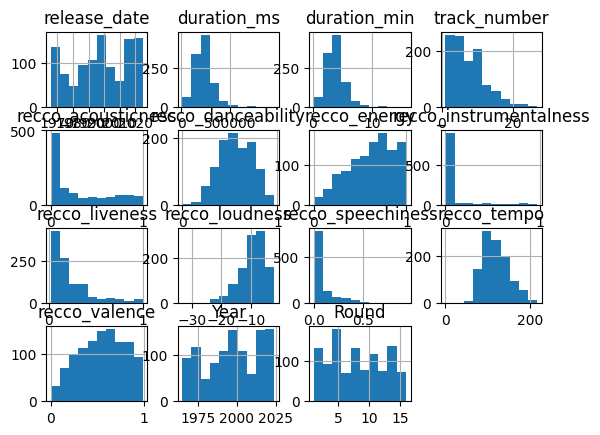

In [650]:
merged_df.hist()

#### Notes:

Some look decently normal - duration, danceability, loudness, tempo. Some look like they need a transformation - acousticness, instrumentalness, speechiness, etc. And some look sort of like they just need to be accepted for who they are - Year, Round, etc.

After that, I wanted to get a sense of what transformations would work for the features in need of it.

0.24019774487365086


array([[<Axes: title={'center': '0'}>]], dtype=object)

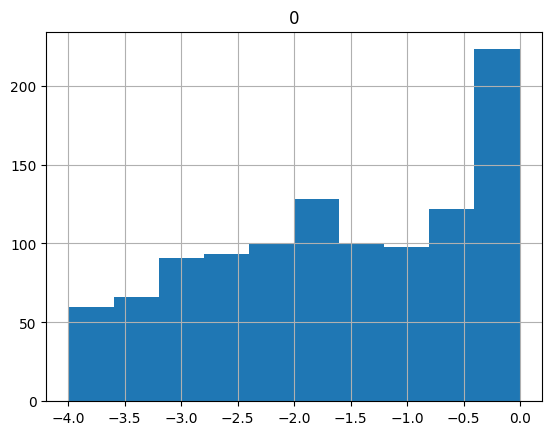

In [651]:
#Acousticness seemed best handled by a Box-Cox transformation
transformed_data, lmbda = stats.boxcox(merged_df['recco_acousticness'])
print(lmbda)
pd.DataFrame(transformed_data).hist()

<Axes: >

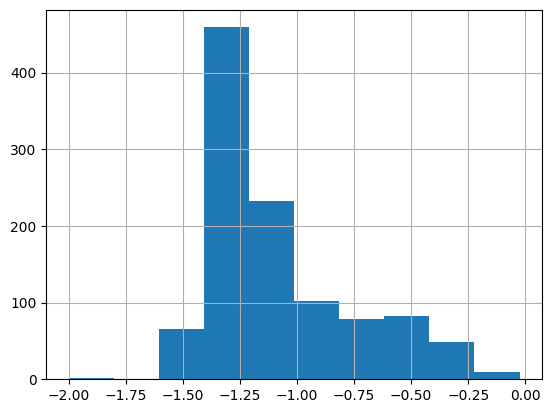

In [652]:
#Speechiness does well with a log transformation after adding a small
#value to avoid undefined values at 0.
np.log10(merged_df["recco_speechiness"]+0.01).hist()

<Axes: >

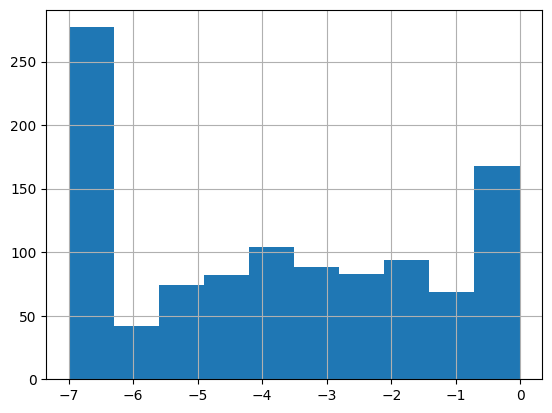

In [653]:
#Instrumentalness does well with a log transformation after adding a
#small value to avoid undefined values at 0.
np.log10(merged_df["recco_instrumentalness"]+0.0000001).hist()

<Axes: >

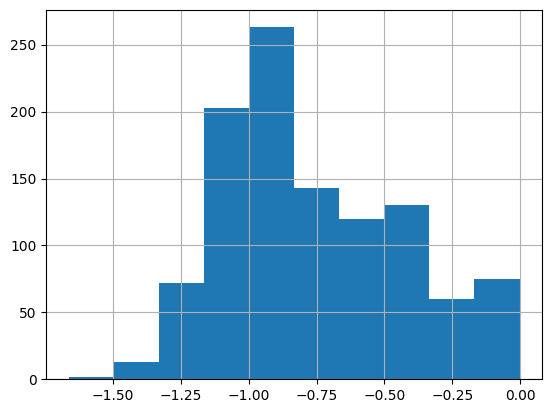

In [654]:
#Liveness does well with a log transformation.
np.log10(merged_df["recco_liveness"]).hist()

In [655]:
merged_df['boxcox_recco_acousticness'] = transformed_data
merged_df['log_recco_speechiness'] = np.log10(merged_df["recco_speechiness"]+0.01)
merged_df['log_recco_instrumentalness'] = np.log10(merged_df["recco_instrumentalness"]+0.0000001)
merged_df['log_recco_liveness'] = np.log10(merged_df["recco_liveness"])

### Notes:

Now, I wanted to subset the data to just the quantitative columns, so that we could normalize the data and then perform dimensionality reduction to look for patterns. After subsetting, the "StandardScaler" call here normalizes the data for further analysis.

In [656]:
quant_cols = ['duration_min', 'recco_danceability', 'recco_energy', 'recco_loudness', 'recco_tempo',
              'recco_valence', 'Year', 'boxcox_recco_acousticness','log_recco_speechiness',
              'log_recco_instrumentalness', 'log_recco_liveness']
quant_df = merged_df[quant_cols]
quant_df['Year'] = quant_df['Year'].values.astype('float64')
scaler = StandardScaler()
quant_df = pd.DataFrame(scaler.fit_transform(quant_df))

/var/folders/31/bkcwt22j275cqd6wbqnvdlvr0000gn/T/ipykernel_53001/2522680686.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quant_df['Year'] = quant_df['Year'].values.astype('float64')


In [657]:
quant_df.columns = quant_cols

array([[<Axes: title={'center': 'duration_min'}>,
        <Axes: title={'center': 'recco_danceability'}>,
        <Axes: title={'center': 'recco_energy'}>],
       [<Axes: title={'center': 'recco_loudness'}>,
        <Axes: title={'center': 'recco_tempo'}>,
        <Axes: title={'center': 'recco_valence'}>],
       [<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'boxcox_recco_acousticness'}>,
        <Axes: title={'center': 'log_recco_speechiness'}>],
       [<Axes: title={'center': 'log_recco_instrumentalness'}>,
        <Axes: title={'center': 'log_recco_liveness'}>, <Axes: >]],
      dtype=object)

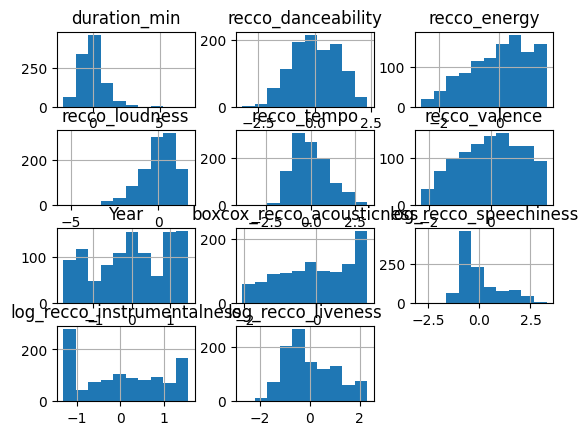

In [658]:
#Post-normalization, everything looks as expected. Distributions are all centered at 0 now,
#with similar variance ranges for the different features.
quant_df.hist()

### Notes:

It's always a good idea to look at how the different features are correlated to each other. This heatmap shows the Pearson correlations, letting me know which features are most correlated in a pairwise fashion.

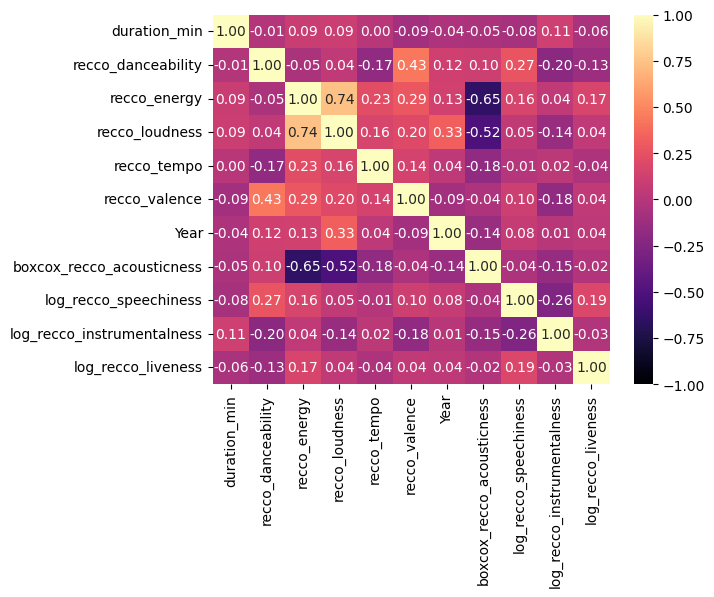

In [659]:
corr_matrix = quant_df.corr()
sns.heatmap(corr_matrix,annot=True, cmap='magma', fmt='.2f', vmin=-1, vmax=1)
plt.show()
#df.columns

### Notes:

We can see that some features have somewhat high correlations, but nothing is shockingly high. Energy and loudness are pretty strongly positively correlated, while acousticness seems pretty negatively correlated with these features. If any two features had a Pearson coefficient above 0.9 or 0.95, we might consider removing one because of redundancy, but this is not the case.

Next, I wanted to reduce the dimensions of the data for visualization. One of my favorite tools for this is UMAP (stands for Uniform Manifold Approximation and Projection). UMAP can take large, multi-dimensional data sets and return a reduced representation of the data (usually 2 dimensions) where the distance between points in the low dimension representation is as close as possible to the distance in the original data. It's not without controversy, but in my experience, UMAP does a pretty good job showing general trends in large complex datasets. UMAP does so by repeatedly following a series of steps (including calculating a graph representation of the data and using gradient descent to position 2D points) until the algorithm converges. You can read more about how UMAP compares to things like Principal Component Analysis at sites like this one (https://aurigait.com/blog/blog-easy-explanation-of-dimensionality-reduction-and-techniques/).

In [660]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(quant_df)

/Users/cusanovich/python_envs/python3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [661]:
umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
merged_umap_df = merged_df
merged_umap_df['UMAP1'] = umap_df['UMAP1']
merged_umap_df['UMAP2'] = umap_df['UMAP2']

### Notes:

Having implemented UMAP, we can now plot the UMAP coordinates and color the points by various features to see which ones help to explain the arrangement of the data in 2D best.

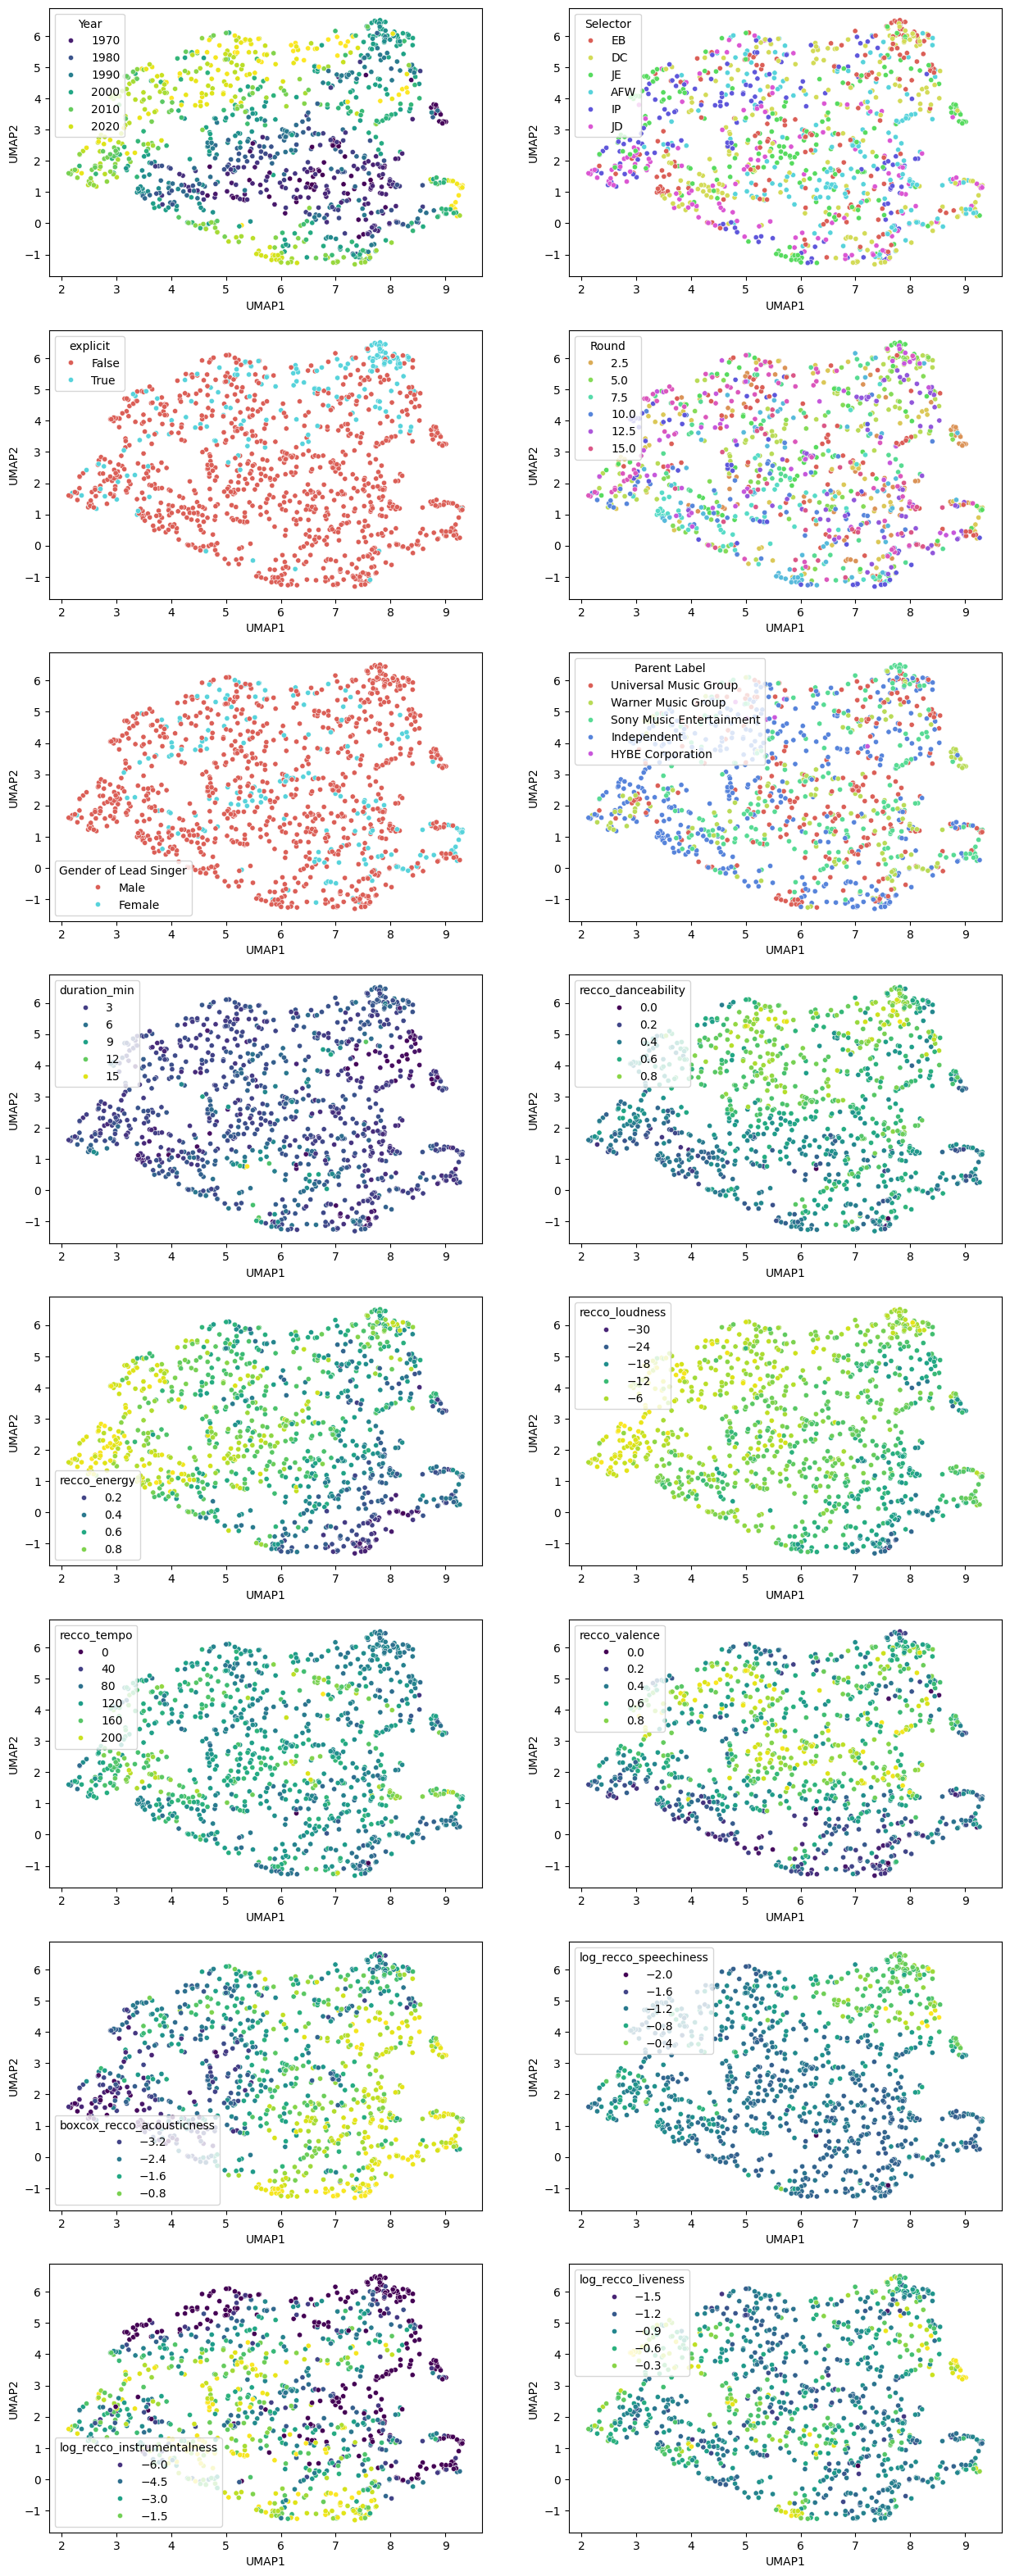

In [662]:
point_size = 20
fig, axs = plt.subplots(8,2,figsize=(15,40))
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='Year', palette='viridis', s=point_size, alpha=1, ax=axs[0,0])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='Selector', palette='hls', s=point_size, alpha=1, ax=axs[0,1])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='explicit', palette='hls', s=point_size, alpha=1, ax=axs[1,0])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='Round', palette='hls', s=point_size, alpha=1, ax=axs[1,1])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='Gender of Lead Singer', palette='hls', s=point_size, alpha=1, ax=axs[2,0])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='Parent Label', palette='hls', s=point_size, alpha=1, ax=axs[2,1])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='duration_min', palette='viridis', s=point_size, alpha=1, ax=axs[3,0])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='recco_danceability', palette='viridis', s=point_size, alpha=1, ax=axs[3,1])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='recco_energy', palette='viridis', s=point_size, alpha=1, ax=axs[4,0])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='recco_loudness', palette='viridis', s=point_size, alpha=1, ax=axs[4,1])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='recco_tempo', palette='viridis', s=point_size, alpha=1, ax=axs[5,0])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='recco_valence', palette='viridis', s=point_size, alpha=1, ax=axs[5,1])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='boxcox_recco_acousticness', palette='viridis', s=point_size, alpha=1, ax=axs[6,0])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='log_recco_speechiness', palette='viridis', s=point_size, alpha=1, ax=axs[6,1])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='log_recco_instrumentalness', palette='viridis', s=point_size, alpha=1, ax=axs[7,0])
sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='log_recco_liveness', palette='viridis', s=point_size, alpha=1, ax=axs[7,1])
plt.show()

### Results:
Some really interesting trends come out!

- Often in UMAP, we can see discrete clusters of points that usually share some features that distinguish that cluster. I would say there is not really strong clustering overall here. However, there does seem to be a separate set of tracks in the upper right that has a distinct feature profile.
- The points in the center of the blob tend to be the oldest songs, while newer ones radiate out.
- All the Club members seem to have picked songs that are spread throughout, indicating that we have diverse and overlapping tastes (at least as measured by these features).
- The explicit songs tend to be in the upper half of the plot, especially in the upper right separating cluster.
- The points are stratified top to bottom by danceability!
- The points are most stratified left to right by acousticness/loudness/energy!
- The upper right separating cluster seems most characterized by increased speechiness!

These are my main findings of this analysis, but I also wanted to share some little anecdotes of digging deeper into the data. First, in looking closer at the data, I noticed that there were two spots that had a lot of points stacked up (see arrows in the plot below), and they both had a lot of songs chosen by the same Club member. I also knew from the plots above that they were scored pretty high for "liveness" and "acousticness". One had some of the older songs we had picked and the other appeared to have some of the newer songs. I suspected each may represent tracks from a single album that just happened to be fairly consistent with each other. So I decided to look a little more deeply.

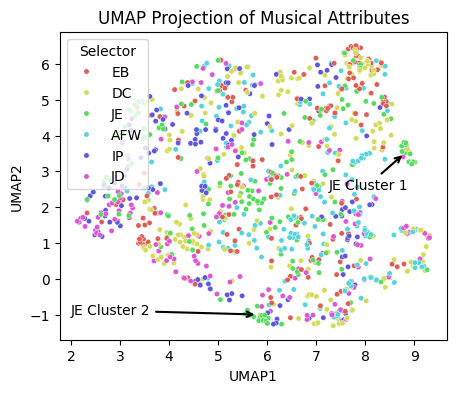

In [663]:
plt.figure(figsize=(5, 4))
ax = sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='Selector', palette='hls', s=15, alpha=1)
ax.annotate('JE Cluster 1', xy=(8.8, 3.5), xytext=(7.25, 2.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5), fontsize=10, color='black')
ax.annotate('JE Cluster 2', xy=(5.8, -1.0), xytext=(2.0, -1.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5), fontsize=10, color='black')
plt.title('UMAP Projection of Musical Attributes')
plt.show()

In [665]:
#Cluster 1 appears to be Ol' Blue Eyes (Frank Sinatra).
merged_umap_df[(merged_umap_df['UMAP1'] > 8.5) & (merged_umap_df['UMAP2'] > 3.0) & (merged_umap_df['Selector'] == 'JE')]['album'].value_counts()

album
Sinatra At The Sands    14
Odelay                   1
Sex Packets              1
Name: count, dtype: int64

In [669]:
#Cluster 2 appears to be Rocket Man (Elton John).
#This album was released in 2020, but it's actually
#a live recording of Elton playing in 1979.
merged_umap_df[(merged_umap_df['UMAP1'] > 5.5) & (merged_umap_df['UMAP1'] < 6.5) & (merged_umap_df['UMAP2'] < -0.5) & (merged_umap_df['Selector'] == 'JE')]['album'].value_counts()

album
Live From Moscow (Live From Moscow / 1979)    16
All Night Live, Vol. 1                         1
Name: count, dtype: int64

### Notes:
Finally, I was really curious what this separating upper-right blob was all about. Why was it different from other tracks? What does the "speechiness" of a song mean? So I decided to look into it further by looking at which albums were most enriched in that cluster.

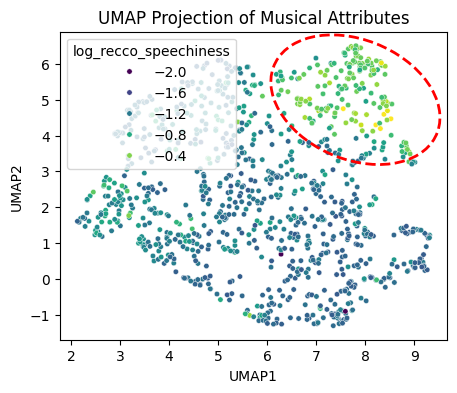

In [667]:
plt.figure(figsize=(5, 4))
ax = sns.scatterplot(data=merged_umap_df, x='UMAP1', y='UMAP2', hue='log_recco_speechiness', palette='viridis', s=15, alpha=1)
ellipse = Ellipse(xy=(7.8, 5.0), width=4, height=3, angle=310, 
                  edgecolor='red', linestyle='--', fc='none', lw=2)

# 4. Add to plot
ax.add_patch(ellipse)
plt.title('UMAP Projection of Musical Attributes')
plt.show()

In [668]:
#Turns out it's mostly rap albums! And Frank Sinatra!
merged_umap_df[(merged_umap_df['UMAP1'] > 7.0) & (merged_umap_df['UMAP2'] > 4.0)]['album'].value_counts().head()

album
Operation: Doomsday (Complete)                             21
Paul's Boutique (20th Anniversary Edition / Remastered)    18
Deltron 3030                                               16
Things Fall Apart                                          16
Aquemini                                                   10
Name: count, dtype: int64

### Take-home Message:
Rap and Frank Sinatra live albums can be largely separated from other music on the basis of "speechiness".

## Next steps:
- In the future, I hope to expand this analysis to identify more informative features. Perhaps find additional features with which I could annotate the tracks. I'd also like to properly cluster the tracks using the leiden algorithm. And perhaps do some linear modelling.
- I'd like to download lyrics to the tracks and see what lyric-based clustering looks like on the albums.
- I'd also like to build a prototype neural network, to see if I can predict which Album Club member chose a particular album, or better yet, which albums a particular Album Club member is likely to choose in the future.